<a href="https://colab.research.google.com/github/tejastatte738566/bank-churn-analysis/blob/main/pharma_analytics_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scipy

✅ Dataset Created: (5000, 13)
   patient_id drug_name   region age_group  gender therapeutic_category  \
0           1     DrugD    South     31-45    Male             Oncology   
1           2     DrugE  Central     61-75    Male             Oncology   
2           3     DrugC     West       75+    Male     Gastroenterology   
3           4     DrugE     West     61-75  Female     Gastroenterology   
4           5     DrugE  Central     61-75  Female           Immunology   

   adverse_event_reported patient_outcome  prescription_count  adherence_rate  \
0                       0           Fatal                 388            0.63   
1                       0         Unknown                 372            0.74   
2                       0      Recovering                 129            0.72   
3                       0         Unknown                 404            0.59   
4                       1       Recovered                 220            0.81   

   sales_units  year quarter  
0

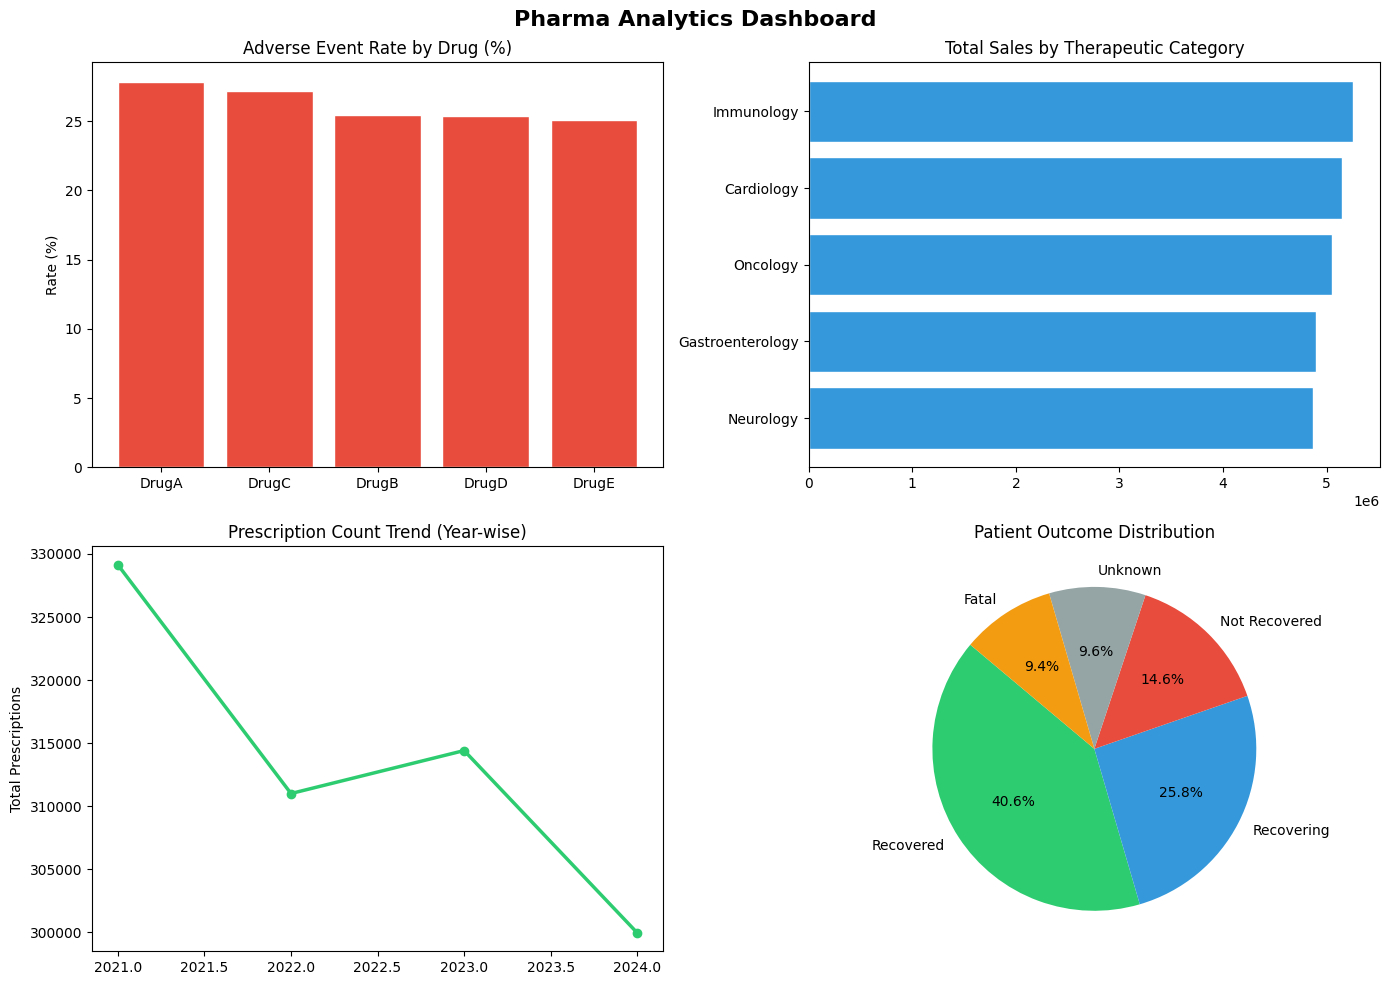

In [ ]:
"""
Pharma Sales & Patient Outcome Analytics
=========================================
Project: Healthcare Data Analyst Resume Project
Dataset: Simulated Pharmaceutical Data (FAERS-inspired)
Author: Your Name
"""

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────
# STEP 1: SIMULATE / LOAD DATASET
# ─────────────────────────────────────────
np.random.seed(42)
n = 5000

drugs = ['DrugA', 'DrugB', 'DrugC', 'DrugD', 'DrugE']
regions = ['North', 'South', 'East', 'West', 'Central']
age_groups = ['18-30', '31-45', '46-60', '61-75', '75+']
genders = ['Male', 'Female']
outcomes = ['Recovered', 'Recovering', 'Not Recovered', 'Fatal', 'Unknown']
categories = ['Oncology', 'Cardiology', 'Neurology', 'Immunology', 'Gastroenterology']

data = pd.DataFrame({
    'patient_id': range(1, n+1),
    'drug_name': np.random.choice(drugs, n),
    'region': np.random.choice(regions, n),
    'age_group': np.random.choice(age_groups, n),
    'gender': np.random.choice(genders, n),
    'therapeutic_category': np.random.choice(categories, n),
    'adverse_event_reported': np.random.choice([0, 1], n, p=[0.75, 0.25]),
    'patient_outcome': np.random.choice(outcomes, n, p=[0.4, 0.25, 0.15, 0.1, 0.1]),
    'prescription_count': np.random.randint(1, 500, n),
    'adherence_rate': np.round(np.random.uniform(0.5, 1.0, n), 2),
    'sales_units': np.random.randint(100, 10000, n),
    'year': np.random.choice([2021, 2022, 2023, 2024], n),
    'quarter': np.random.choice(['Q1', 'Q2', 'Q3', 'Q4'], n),
})

print("✅ Dataset Created:", data.shape)
print(data.head())

# ─────────────────────────────────────────
# STEP 2: DATA CLEANING
# ─────────────────────────────────────────
print("\n🔍 Null Values:\n", data.isnull().sum())
data.drop_duplicates(inplace=True)
data['adherence_rate'] = data['adherence_rate'].clip(0, 1)
print("✅ Data Cleaned. Rows:", len(data))

# ─────────────────────────────────────────
# STEP 3: DATABASE SETUP (SQLite)
# ─────────────────────────────────────────
conn = sqlite3.connect('pharma_analytics.db')
data.to_sql('patient_drug_data', conn, if_exists='replace', index=False)
print("\n✅ Data stored in SQLite DB: pharma_analytics.db")

# SQL Query Example
query = """
SELECT drug_name,
       COUNT(*) as total_patients,
       SUM(adverse_event_reported) as total_adverse_events,
       ROUND(AVG(adherence_rate)*100, 2) as avg_adherence_pct,
       SUM(sales_units) as total_sales
FROM patient_drug_data
GROUP BY drug_name
ORDER BY total_adverse_events DESC
"""
drug_summary = pd.read_sql(query, conn)
print("\n📊 Drug Summary from SQL:\n", drug_summary)

# ─────────────────────────────────────────
# STEP 4: ANALYSIS
# ─────────────────────────────────────────

# 4a. Adverse Event Rate by Drug
adverse_rate = data.groupby('drug_name')['adverse_event_reported'].mean().sort_values(ascending=False)
print("\n⚠️ Adverse Event Rate by Drug:\n", adverse_rate)

# 4b. Regional Prescription Trends
region_trend = data.groupby(['region', 'year'])['prescription_count'].sum().reset_index()

# 4c. Correlation: Adherence vs Adverse Events
corr, pval = stats.pointbiserialr(data['adverse_event_reported'], data['adherence_rate'])
print(f"\n📈 Correlation (Adherence vs Adverse Events): r={corr:.3f}, p={pval:.4f}")

# 4d. KPIs
total_patients = len(data)
adverse_event_rate = data['adverse_event_reported'].mean() * 100
avg_adherence = data['adherence_rate'].mean() * 100
recovery_rate = (data['patient_outcome'] == 'Recovered').mean() * 100
total_sales = data['sales_units'].sum()

print(f"""
📌 KEY PERFORMANCE INDICATORS
──────────────────────────────
Total Patients Analyzed : {total_patients:,}
Adverse Event Rate      : {adverse_event_rate:.1f}%
Average Adherence Rate  : {avg_adherence:.1f}%
Recovery Rate           : {recovery_rate:.1f}%
Total Sales Units       : {total_sales:,}
""")

# ─────────────────────────────────────────
# STEP 5: VISUALIZATIONS
# ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pharma Analytics Dashboard', fontsize=16, fontweight='bold')

# Plot 1: Adverse Event Rate by Drug
axes[0,0].bar(adverse_rate.index, adverse_rate.values * 100, color='#E74C3C', edgecolor='white')
axes[0,0].set_title('Adverse Event Rate by Drug (%)')
axes[0,0].set_ylabel('Rate (%)')

# Plot 2: Sales by Therapeutic Category
cat_sales = data.groupby('therapeutic_category')['sales_units'].sum().sort_values()
axes[0,1].barh(cat_sales.index, cat_sales.values, color='#3498DB', edgecolor='white')
axes[0,1].set_title('Total Sales by Therapeutic Category')

# Plot 3: Prescription Trend by Year
year_trend = data.groupby('year')['prescription_count'].sum()
axes[1,0].plot(year_trend.index, year_trend.values, marker='o', color='#2ECC71', linewidth=2.5)
axes[1,0].set_title('Prescription Count Trend (Year-wise)')
axes[1,0].set_ylabel('Total Prescriptions')

# Plot 4: Patient Outcome Distribution
outcome_counts = data['patient_outcome'].value_counts()
axes[1,1].pie(outcome_counts.values, labels=outcome_counts.index,
              autopct='%1.1f%%', startangle=140,
              colors=['#2ECC71','#3498DB','#E74C3C','#95A5A6','#F39C12'])
axes[1,1].set_title('Patient Outcome Distribution')

plt.tight_layout()
plt.savefig('pharma_dashboard_charts.png', dpi=150, bbox_inches='tight')
print("✅ Charts saved: pharma_dashboard_charts.png")

conn.close()
print("\n✅ All analysis complete!")


In [ ]:
from google.colab import files
files.download('pharma_dashboard_charts.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>